Os dados foram baixados do seguinte link disponibilizado no PDF do desafio -> https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data


In [ ]:
#Importe dos dados

import pandas as pd

df = pd.read_csv("/diabetes.csv")

#Verificando o tamanho da base e a dimencionalidade
df.shape

(768, 9)

In [ ]:
#Verificando se alguma coluna possui dados nulos ou faltntes
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Não há dados null, não sendo necessário fazer esse tratamento dos dados


In [ ]:
df.isnull().sum()

,count
Outcome,
0,500
1,268


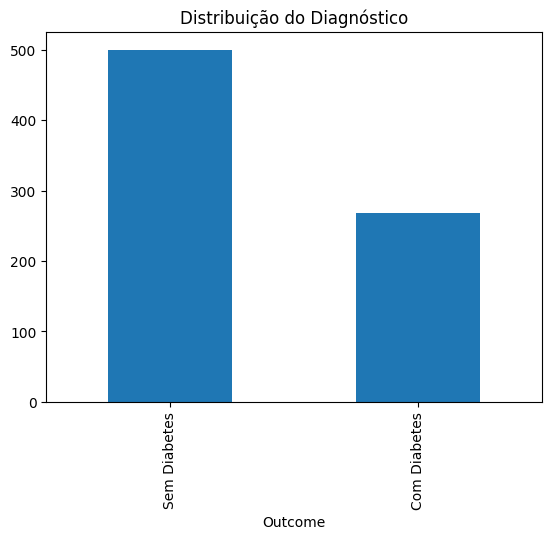

In [ ]:
#Verificando a distribuição entre Diagnosticos positivos e negativos

import matplotlib.pyplot as plt

df["Outcome"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Sem Diabetes", "Com Diabetes"])
plt.title("Distribuição do Diagnóstico")
plt.show()

In [ ]:
#Verificando COlunas Existentes
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
#Verificando quais são os tipos de dados na base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Não há nenhum dado string categório, não sendo preciso fazer esse tipo de tratamento nos dados.


In [ ]:
#Verificando as estatísticas completas
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

cols_com_zero_invalido = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

#Separação dos dados entre treino e teste
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Tratamento dos dados
X_train[cols_com_zero_invalido] = X_train[cols_com_zero_invalido].replace(0, np.nan)
X_test[cols_com_zero_invalido] = X_test[cols_com_zero_invalido].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')

X_train[cols_com_zero_invalido] = imputer.fit_transform(X_train[cols_com_zero_invalido])
X_test[cols_com_zero_invalido] = imputer.transform(X_test[cols_com_zero_invalido])

print(f"Treino: {X_train.shape[0]}")
print(f"Teste: {X_test.shape[0]}")

Treino: 614
Teste: 154


Foi adicionado a estratégia de amostragem estratificada (stratify=y), para que seja garantido que a proporção original de diagnósticos positivos e negativos fosse mantida em ambas as partições.

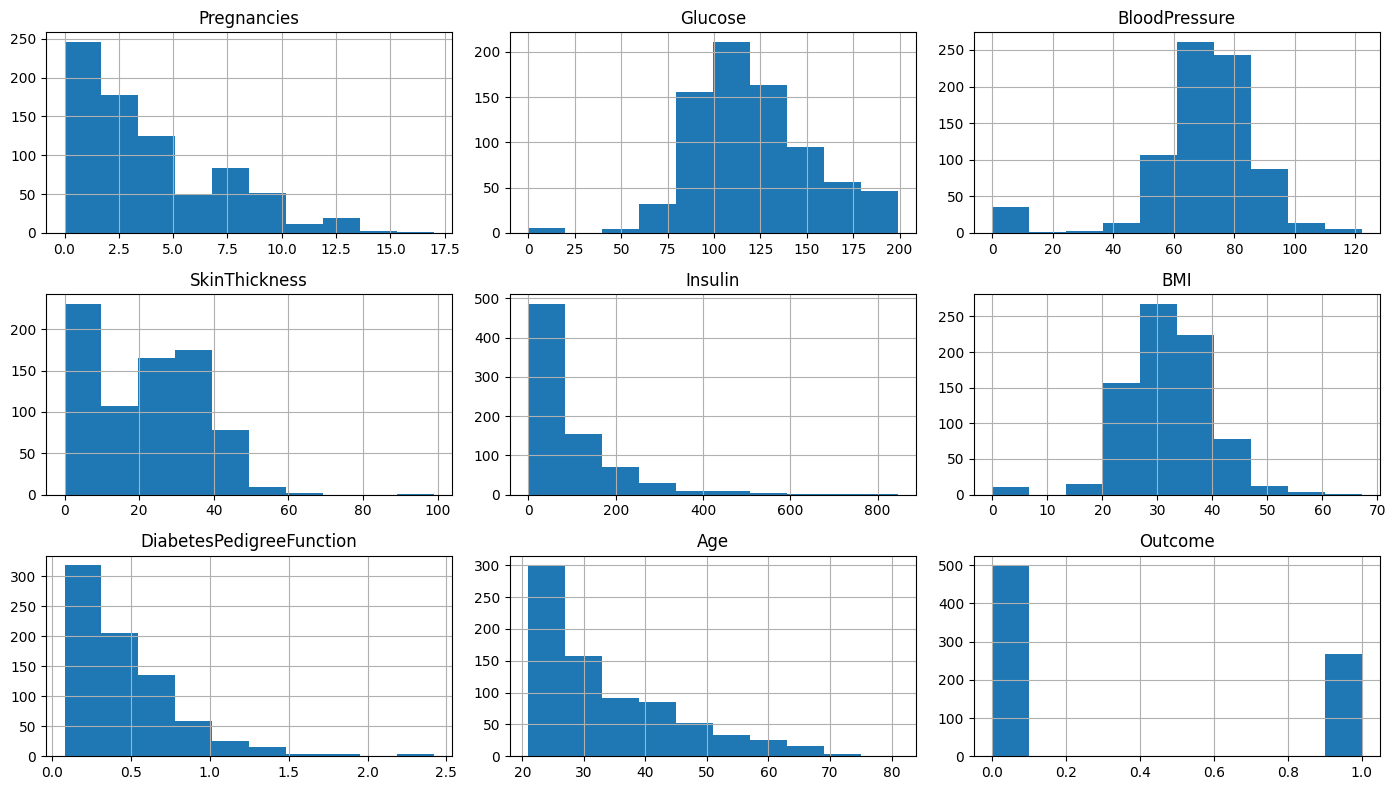

In [ ]:
#Histograma
import matplotlib.pyplot as plt

df.hist(figsize=(14,8))
plt.tight_layout()
plt.show()

Observando os histogramas gerados, podemos entender os seguintes pontos:

Existe uma assimetria à direita, ou seja as variáveis Age, Pregnancies, DiabetesPedigreeFunction e Insulin apresentam forte assimetria positiva, o que pode estar indicando que a maior parte da população do estudo é jovem, teve poucas gestações e possui histórico genético/nível de insulina concentrado em valores baixos.
Podmos perceber que existe um desbalanceamento de classes, pois a barra do valor 0 é significativamente maior do que a do valor 1, evidenciando o desbalanceamento onde aproximadamente 65% da base representa indivíduos não diabéticos.

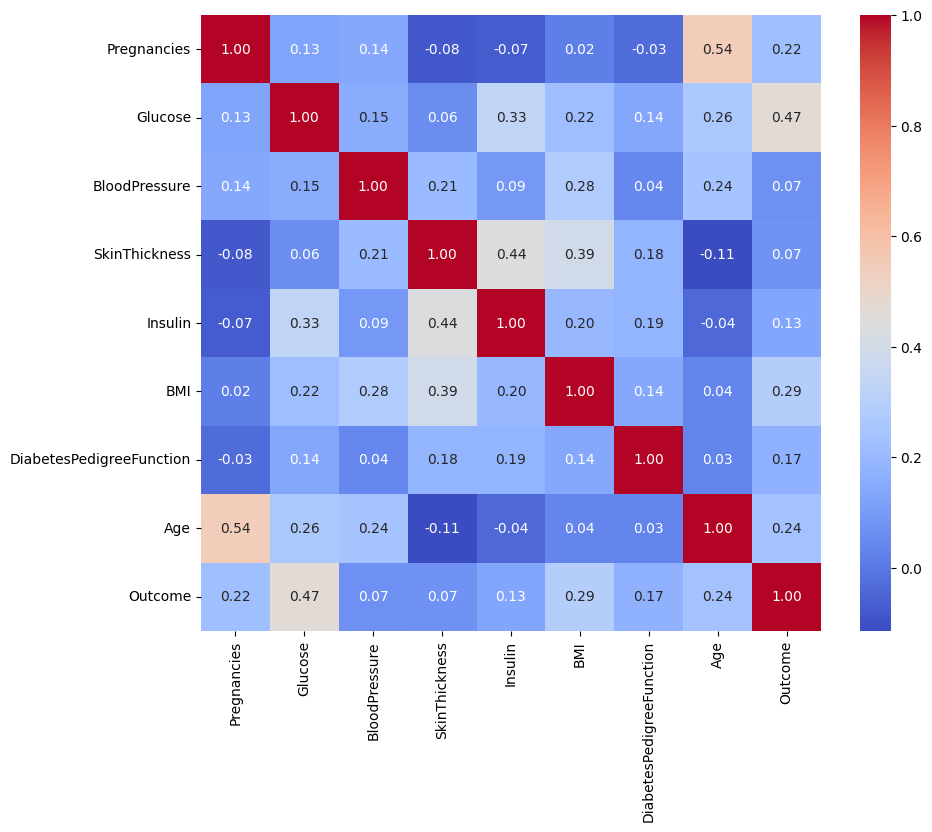

In [ ]:
#Matriz de Correlação
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Observando a matriz de correlação podemos verificar que a variável alvo possui uma correlação mais forte com a variável GLUCOSE, a segunda maior correlação é o BMI, que consiste no índice de Massa Corporal.

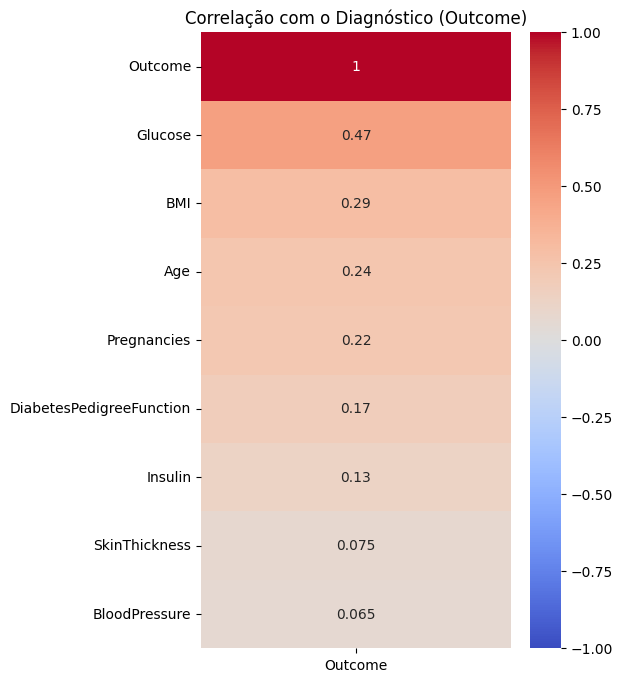

In [ ]:
#Verificando a Correlação das classes com o diagnóstico
import matplotlib.pyplot as plt
import seaborn as sns


corr = df.corr(numeric_only=True)
plt.figure(figsize=(5, 8))
sns.heatmap(
    corr[["Outcome"]].sort_values(by="Outcome", ascending=False),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

plt.title("Correlação com o Diagnóstico (Outcome)")
plt.show()

Analisando separadamente a correlção com a variável de resultado outcome, podemos verificar que visualmente GLUCOSE é de fato a variável com maior assocciação linear com o diagnóstico seguida do BMI. Podemos observar que não há características analisadas com correlação inversa (valores negativos), o que significa que o aumento de qualquer um dos fatores está relacionado com um risco maior de diabetes.

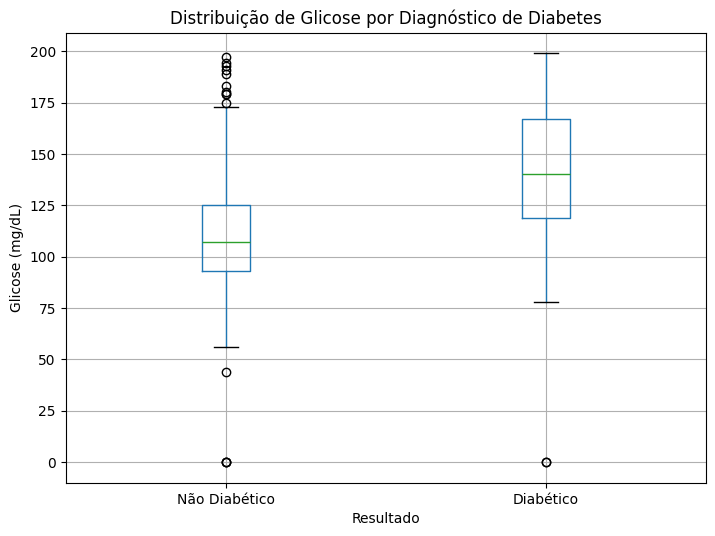

In [ ]:
import matplotlib.pyplot as plt


df.boxplot(column="Glucose", by="Outcome", figsize=(8, 6))

# (0 = Não Diabético, 1 = Diabético)
plt.xticks([1, 2], ["Não Diabético", "Diabético"])


#Gráfico
plt.title("Distribuição de Glicose por Diagnóstico de Diabetes")
plt.suptitle("")
plt.ylabel("Glicose (mg/dL)")
plt.xlabel("Resultado")

plt.show()

Analisando os dados e os gráficos, podemos perceber que os pacientes diagnosticados com diabetes apresentam níveis de glicose significativamente mais altos, com a mediana em torno de 140 mg/dL contra 108 mg/dL dos não diabéticos. O grupo não diabético é mais concentrado, mas possui diversos outliers com glicose alta, indicando pessoas em estado de alerta (pré-diabetes) que ainda não desenvolveram a doença.


In [ ]:
#Escalonamento dos dados

from sklearn.preprocessing import StandardScaler

# Inicializa o padronizador, importante para a Regressão Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Modelos escolhidos para a classificação: Random Forest e Regressão Logística

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Inicialização da Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

# Treinamento da Random Forest com os dados escalonados
modelo_rf.fit(X_train_scaled, y_train)

#Utilizando o modelo para Predição
y_pred = modelo_rf.predict(X_test_scaled)

#Avaliando a acurácia do Modelo
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acuracia * 100:.2f}%\n")

#Relatório Completo
from sklearn.metrics import accuracy_score, classification_report

print("Relatório de Classificação:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Sem Diabetes", "Com Diabetes"]
))

Acurácia: 74.03%

Relatório de Classificação:
              precision    recall  f1-score   support

Sem Diabetes       0.82      0.72      0.76        99
Com Diabetes       0.58      0.71      0.64        55

    accuracy                           0.71       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



A acurácia de 75.97% é considerada baixa, ainda mais em um contexto médico. Pode ser um indicativo de overfitting (Quando o modelo decora os dados de treino). No próximo bloco foi adicionado um tratamento para esse caso.

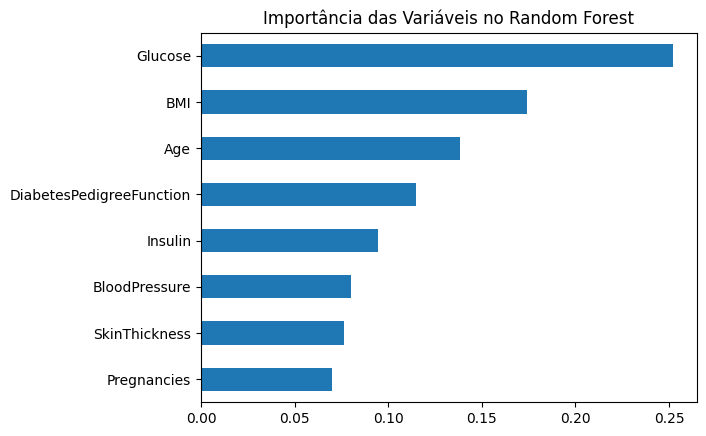

In [ ]:
# Verificando as variáveis mais importante no Random Forest
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias.sort_values().plot(kind='barh')
plt.title("Importância das Variáveis no Random Forest")
plt.show()

In [ ]:
# Remoção das colunas menos importantes
features_selecionadas = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin', 'BloodPressure']
X_train_filtrado = X_train[features_selecionadas]
X_test_filtrado = X_test[features_selecionadas]

# Novo treino do modelo
modelo_rf.fit(X_train_filtrado, y_train)
y_pred_novo = modelo_rf.predict(X_test_filtrado)
print(f"Nova acurácia: {accuracy_score(y_test, y_pred_novo) * 100:.2f}%")

Nova acurácia: 77.27%


In [ ]:
#Relatório Completo

from sklearn.metrics import accuracy_score, classification_report

print("Relatório de Classificação:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Sem Diabetes", "Com Diabetes"]
))

Relatório de Classificação:
              precision    recall  f1-score   support

Sem Diabetes       0.82      0.72      0.76        99
Com Diabetes       0.58      0.71      0.64        55

    accuracy                           0.71       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



Houve uma melhora na acurácia.

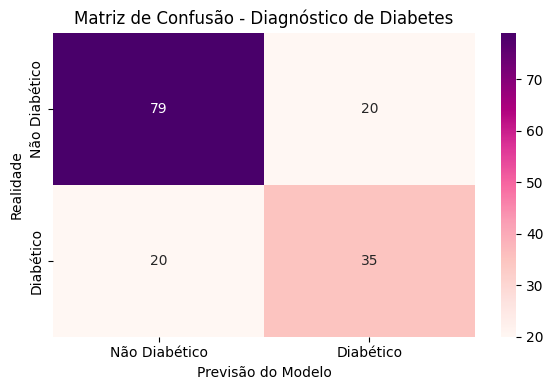

In [ ]:
#Avaliando melhor falsos NEGATIVOS e falsos POSITIVOS com a Matriz de Confusão
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

classes = ["Não Diabético", "Diabético"]

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdPu",
    xticklabels=classes,
    yticklabels=classes
)

plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.title('Matriz de Confusão - Diagnóstico de Diabetes')
plt.tight_layout()
plt.show()

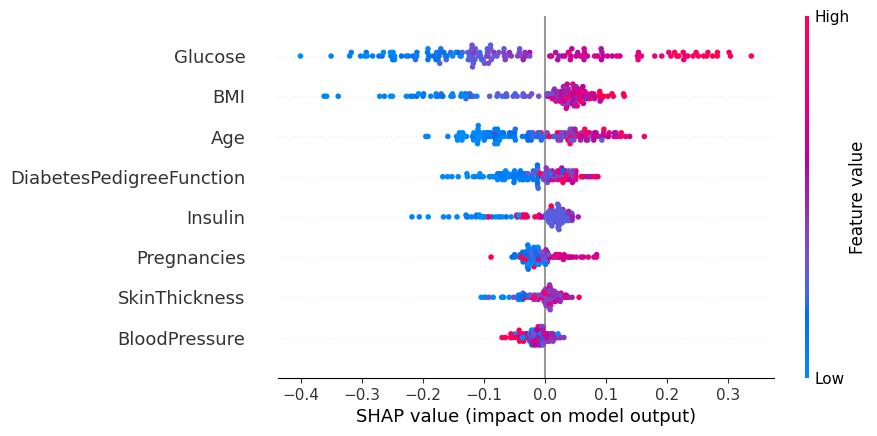

In [ ]:
#Aplicação da técnica SHAP

import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
modelo_rf.fit(X_train_scaled_df, y_train)

explainer = shap.TreeExplainer(modelo_rf)
shap_values_obj = explainer(X_test_scaled_df)

# Isola a classe positiva (1 = Diabético)
if len(shap_values_obj.shape) == 3:
    shap_values_classe_positiva = shap_values_obj[:, :, 1]
else:
    shap_values_classe_positiva = shap_values_obj

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_classe_positiva)

A utilização da técnica SHAP confirma que Glucose e BMI são as variáveis mais críticas, onde valores altos (pontos vermelhos) aumentam drasticamente a chance de o modelo prever diabetes. As variáveis Age e DiabetesPedigreeFunction atuam como fatores secundários de risco progressivo ao longo do ciclo de vida e histórico genético. Já os SkinThickness e BloodPressure formam um bloco neutro no centro, mostrando assim que os mesmos possuem impacto nulo na decisão do algoritmo.

In [ ]:
#Regressão Logística

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelo_lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000,
    C=1.0
)

modelo_lr.fit(X_train_filtrado, y_train)
y_pred_lr = modelo_lr.predict(X_test_filtrado)

acuracia_lr = accuracy_score(y_test, y_pred_lr)
print(f"Acurácia Regressão Logística: {acuracia_lr * 100:.2f}%")

Acurácia Regressão Logística: 71.43%


In [ ]:
#Relatório Completo

from sklearn.metrics import accuracy_score, classification_report

print("Relatório de Classificação:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Sem Diabetes", "Com Diabetes"]
))

Relatório de Classificação:
              precision    recall  f1-score   support

Sem Diabetes       0.82      0.72      0.76        99
Com Diabetes       0.58      0.71      0.64        55

    accuracy                           0.71       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



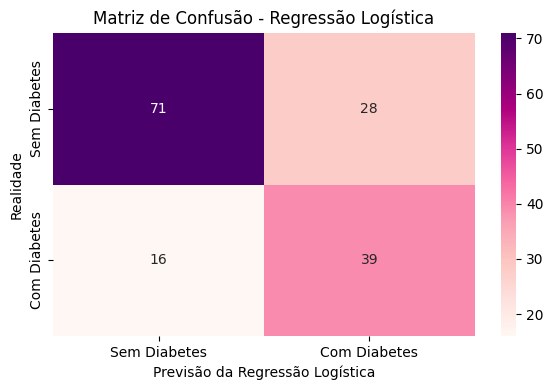

In [ ]:
#Matriz de Confusão

cm_lr = confusion_matrix(y_test, y_pred_lr)
labels = ["Sem Diabetes", "Com Diabetes"]

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="RdPu",
    xticklabels=labels,
    yticklabels=labels
)

plt.ylabel('Realidade')
plt.xlabel('Previsão da Regressão Logística')
plt.title('Matriz de Confusão - Regressão Logística')
plt.tight_layout()
plt.show()

Analisando a matriz de confusão podemos observar que o modelo cometeu 44 erros no total: 28 Falsos Positivos, ou seja, o modelo alarmou que 28 pessoas saudáveis tinham diabetes. O que não é o ideal, uma vez que em um cenário médico, isso gera custos com exames adicionais desnecessários e estresse para o paciente. O modelo também relatou 16 Falsos Negativos, que é o erro mais perigoso. O modelo disse que 16 pessoas eram saudáveis, mas elas realmente têm diabetes. O que não é ideal, uma vez que esses pacientes voltariam para casa sem o tratamento adequado.

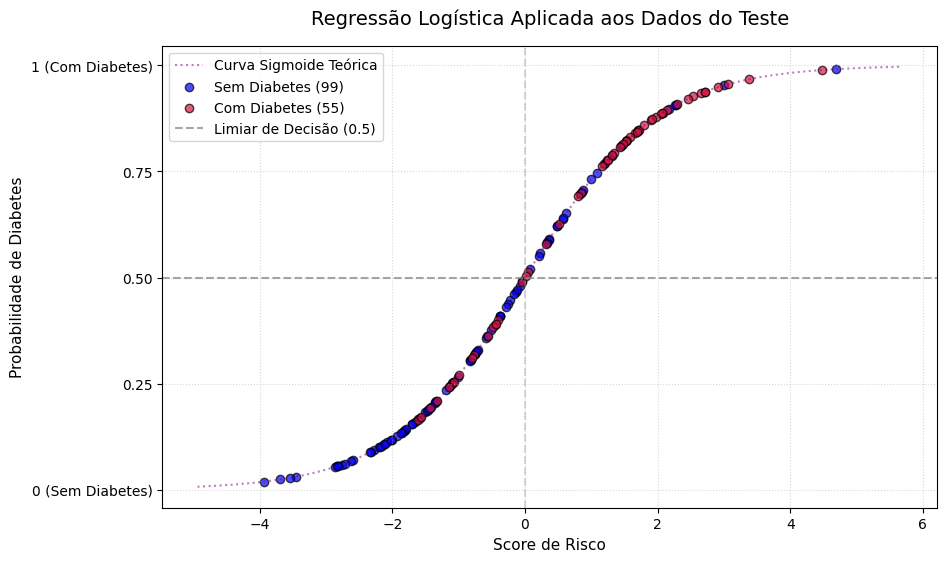

In [ ]:
#Visualização no gráfico

import numpy as np
import matplotlib.pyplot as plt

scores = modelo_lr.decision_function(X_test_filtrado)
probabilidades = modelo_lr.predict_proba(X_test_filtrado)[:, 1]

n_sem_diabetes = np.sum(y_test == 0)
n_com_diabetes = np.sum(y_test == 1)

x_curva = np.linspace(scores.min() - 1, scores.max() + 1, 300)
y_curva = 1 / (1 + np.exp(-x_curva))

plt.figure(figsize=(10, 6))
plt.plot(x_curva, y_curva, color='purple', linestyle=':', alpha=0.5, label='Curva Sigmoide Teórica')

plt.scatter(scores[y_test == 0], probabilidades[y_test == 0],
            color='blue', alpha=0.7, edgecolors='k', label=f'Sem Diabetes ({n_sem_diabetes})')
plt.scatter(scores[y_test == 1], probabilidades[y_test == 1],
            color='crimson', alpha=0.7, edgecolors='k', label=f'Com Diabetes ({n_com_diabetes})')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Limiar de Decisão (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

plt.title('Regressão Logística Aplicada aos Dados do Teste', fontsize=14, pad=15)
plt.xlabel('Score de Risco', fontsize=11)
plt.ylabel('Probabilidade de Diabetes', fontsize=11)
plt.yticks([0, 0.25, 0.5, 0.75, 1.0], ['0 (Sem Diabetes)', '0.25', '0.50', '0.75', '1 (Com Diabetes)'])

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

gráfico da curva sigmoide mostra que a Regressão Logística calcula a probabilidade mapeando o score de risco de cada paciente de forma contínua. Os pontos azuis (saudáveis) predominam no lado esquerdo com probabilidades baixas, enquanto os pontos vermelhos (diabéticos) se concentram à direita acima do limiar de 0.50. Mas consiguimos verificar que há uma visível sobreposição de cores perto do centro do gráfico, indicando os erros de classificação (falsos positivos e falsos negativos) que limitam a acurácia do modelo linear. Essa mistura ocorre principalmente porque as variáveis mais importantes reveladas no Random Forest, como Glucose e BMI, possuem relações não-lineares complexas na zona de transição da doença.

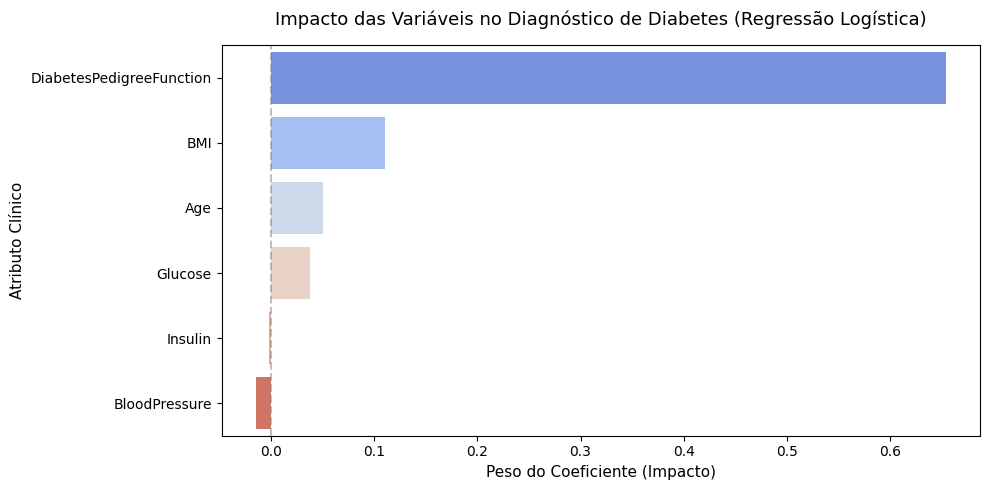

In [ ]:
#Gráfico de Impacto das Variáveis

coeficientes = modelo_lr.coef_[0]
df_coef = pd.DataFrame({'Variável': X_train_filtrado.columns, 'Coeficiente': coeficientes})
df_coef = df_coef.sort_values(by='Coeficiente', ascending=False)


plt.figure(figsize=(10, 5))
sns.barplot(
    x='Coeficiente',
    y='Variável',
    data=df_coef,
    hue='Variável',
    legend=False,
    palette='coolwarm'
)

plt.title('Impacto das Variáveis no Diagnóstico de Diabetes (Regressão Logística)', fontsize=13, pad=15)
plt.xlabel('Peso do Coeficiente (Impacto)', fontsize=11)
plt.ylabel('Atributo Clínico', fontsize=11)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

O gráfico de coeficientes nos mostra que a Regressão Logística considera o histórico genético (DiabetesPedigreeFunction) e o BMI como os fatores matemáticos de maior peso para empurrar o diagnóstico para positivo. Diferente do Random Forest (onde a glicose dominava), o modelo linear foca na escala das variáveis, mantendo a Insulin neutra e atribuindo um peso sutilmente negativo à BloodPressure. Podemos concluir nesse caso que como modelos lineares e baseados em árvores interpretam o risco clínico sob perspectivas matemáticas completamente diferentes.

Total de casos no teste: 154
Casos onde os modelos discordaram: 18



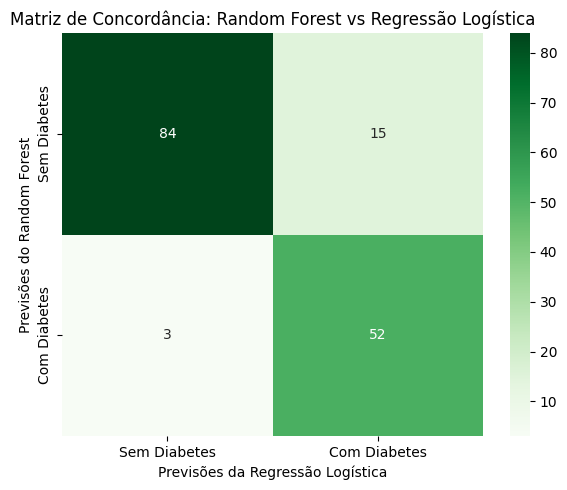

In [ ]:

prob_rf = modelo_rf.predict_proba(X_test_scaled_df if 'X_test_scaled_df' in locals() else X_test_scaled)[:, 1]
prob_lr = modelo_lr.predict_proba(X_test_filtrado)[:, 1]

df_validacao = pd.DataFrame({
    'Realidade': y_test.values,
    'Pred_RandomForest': y_pred if 'y_pred' in locals() else modelo_rf.predict(X_test_scaled_df if 'X_test_scaled_df' in locals() else X_test_scaled),
    'Prob_RandomForest': prob_rf,
    'Pred_RegLogistica': y_pred_lr,
    'Prob_RegLogistica': prob_lr
})

df_discordancia = df_validacao[df_validacao['Pred_RandomForest'] != df_validacao['Pred_RegLogistica']].copy()
print(f"Total de casos no teste: {len(df_validacao)}")
print(f"Casos onde os modelos discordaram: {len(df_discordancia)}\n")

plt.figure(figsize=(6, 5))
cm_modelos = confusion_matrix(df_validacao['Pred_RandomForest'], df_validacao['Pred_RegLogistica'])
sns.heatmap(cm_modelos, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Sem Diabetes", "Com Diabetes"],
            yticklabels=["Sem Diabetes", "Com Diabetes"])
plt.title("Matriz de Concordância: Random Forest vs Regressão Logística")
plt.xlabel("Previsões da Regressão Logística")
plt.ylabel("Previsões do Random Forest")
plt.tight_layout()
plt.show()

A matriz mostra uma alta concordância geral entre os modelos, que decidiram juntos o mesmo diagnóstico em 136 dos 154 casos totais. A maior concordancia acontece ao descartar a doença, acumulando 84 decisões conjuntas para "Sem Diabetes". No entanto, os algoritmos divergiram  em 18 pacientes. Em 15 ocasiões, a Regressão Logística previu diabetes enquanto o Random Forest tendeu a poupar o paciente.